# EfficientNetV2 B0

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetV2B0
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam

import wandb
from wandb.integration.keras import WandbCallback,  WandbMetricsLogger

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os
import random

Setting a seed

In [ ]:
def set_seeds(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_seeds(5)

Loading the CIFAR-10

In [ ]:
from tensorflow.keras.datasets import cifar10
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

In [ ]:
X_train.shape

(50000, 32, 32, 3)

Pre-process the data

In [ ]:
from tensorflow.keras.layers import Rescaling
# Convert labels to one-hot vectors
class_names = [
  'airplane',
  'automobile',
  'bird',
  'cat',
  'deer',
  'dog' ,
  'frog' ,
  'horse',
  'ship',
  'truck'
  ]
num_classes = len(class_names)
y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_test_cat = to_categorical(y_test, num_classes=num_classes)

# # Create a preprocessing layer for normalization
# normalization_layer = Rescaling(1./255)
# X_train = normalization_layer(X_train)
# X_test = normalization_layer(X_test)

In [ ]:
X_train_resized = tf.image.resize(X_train, (112, 112))
X_test_resized = tf.image.resize(X_test, (112, 112))

Load EfficientNetV2 B0

In [ ]:
# Build transfer learning model
base_model = EfficientNetV2B0(input_shape=(112, 112, 3), include_top=False, weights='imagenet')
base_model.trainable = False  # Freeze base

24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Add a custom classifier on top

In [ ]:
lr = 1e-3
epochs = 100
batch_size = 128

# from tensorflow.keras import layers, models
model_transfer = Sequential([
    base_model,
    GlobalAveragePooling2D(), # Pool spatial features into a vector
    Dense(128, activation='relu'), # Fully connected layer to learn new patterns
    Dense(10, activation='softmax') # Output layer with 10 classes (Fashion MNIST)
])

opt = Adam(learning_rate=lr)

## Freeze the base

In [ ]:
### Compile the model
model_transfer.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
# Setup data augmentation
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

datagen.fit(X_train_resized) ##X_train_resized X_train

# Setup EarlyStopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',   # metric to monitor
    patience=10,           # stop if no improvement after n epochs
    restore_best_weights=True
)


In [ ]:
 !wandb login

wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter: 
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: alexcardenasgutierrez (alexcardenasgutierrez-ironhack) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [ ]:
### Group account
name = "EfficientNetV2B0Model_freeze112"

wandb.init(
    entity="Ironhack_cnn_project",                  # ← your team name
    project="cifar10_dataset_FantasticFour",  # ← project gets created automatically!
    name= name,
    config={                    # hyperparameters to track
        "epochs": epochs,
        "batch_size": batch_size,
        "optimizer": "adam",
        "learning_rate": lr,
        "augmentation": True
    }
)

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: alexcardenasgutierrez (alexcardenasgutierrez-ironhack) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Training and evaluationg the model

In [ ]:
# Train with WandbCallback
history = model_transfer.fit(
    datagen.flow(X_train_resized, y_train_cat, batch_size=batch_size, shuffle=True),
    epochs=epochs,
    validation_data=(X_test_resized, y_test_cat),
    callbacks=[
        early_stopping,
        WandbMetricsLogger(log_freq="epoch")  # logs everything!
    ]
)



/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 214s 460ms/step - accuracy: 0.7748 - loss: 0.6979 - val_accuracy: 0.8806 - val_loss: 0.3450
Epoch 2/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 134s 344ms/step - accuracy: 0.8580 - loss: 0.4079 - val_accuracy: 0.8894 - val_loss: 0.3211
Epoch 3/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 135s 345ms/step - accuracy: 0.8691 - loss: 0.3711 - val_accuracy: 0.8946 - val_loss: 0.3129
Epoch 4/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 135s 344ms/step - accuracy: 0.8813 - loss: 0.3390 - val_accuracy: 0.8954 - val_loss: 0.3019
Epoch 5/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 134s 343ms/step - accuracy: 0.8834 - loss: 0.3320 - val_accuracy: 0.8951 - val_loss: 0.3041
Epoch 6/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 135s 345ms/step - accuracy: 0.8899 - loss: 0.3174 - val_accuracy: 0.8985 - val_loss: 0.2948
Epoch 7/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 134s 344ms/step - accuracy: 0.8939 - loss: 0.3039 - val_accuracy: 0.8969 - val_loss: 0.2944
Epoch 8/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 134s 343ms/step - accuracy: 

In [ ]:
train_loss, train_acc = model_transfer.evaluate(datagen.flow(X_train_resized, y_train_cat, batch_size=batch_size), verbose=0)
test_loss, test_acc = model_transfer.evaluate(X_test_resized, y_test_cat, verbose=0)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
## Store locally
model_transfer.save(f"{name}.keras")

In [ ]:
model_transfer.save(f"{name}.h5")

In [ ]:
model_transfer=tf.keras.models.load_model('/content/EfficientNetV2B0Model_freeze112.keras')

In [ ]:
# Predict class probabilities
y_pred_probs = model_transfer.predict(X_test_resized)
# Convert probabilities to class predictions
y_pred = y_pred_probs.argmax(axis=1)
# y_pred = model_deeper.predict(X_test).argmax(axis=1)
y_true = y_test  # original integer labels

313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 27ms/step


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
# Compute metrics
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='weighted')
rec = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 0.9037
Precision: 0.9038
Recall: 0.9037
F1 Score: 0.9034


In [ ]:
from sklearn.metrics import classification_report

report = classification_report(y_test, y_pred, target_names=class_names)
print(report)

              precision    recall  f1-score   support

    airplane       0.93      0.88      0.91      1000
  automobile       0.94      0.94      0.94      1000
        bird       0.92      0.88      0.90      1000
         cat       0.83      0.79      0.81      1000
        deer       0.87      0.91      0.89      1000
         dog       0.85      0.87      0.86      1000
        frog       0.91      0.93      0.92      1000
       horse       0.95      0.94      0.94      1000
        ship       0.92      0.95      0.93      1000
       truck       0.91      0.95      0.93      1000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



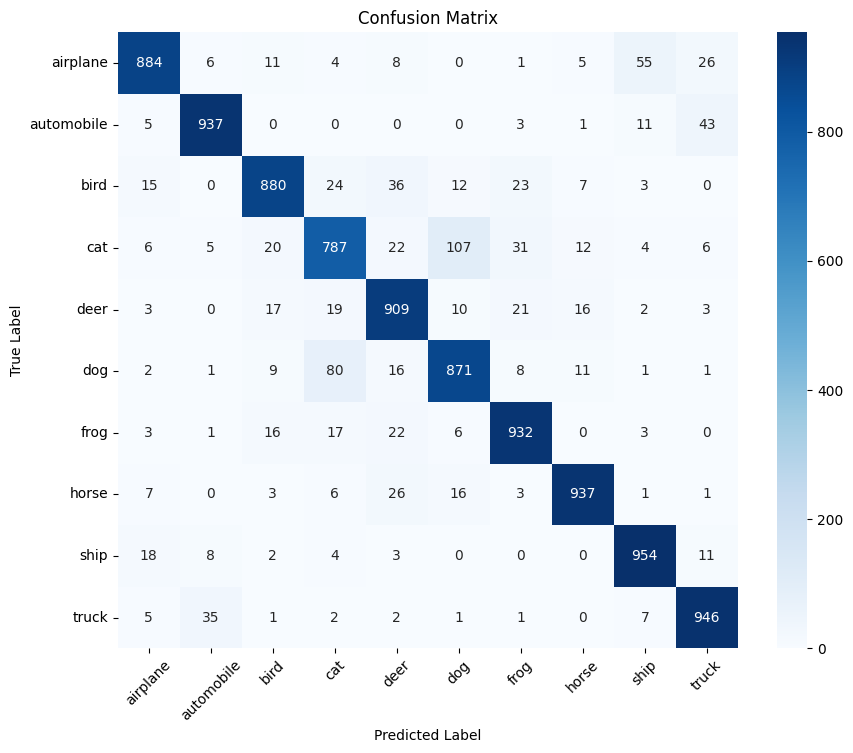

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

In [ ]:
# Log summary table to wandb
wandb.log({
    "summary_table": wandb.Table(
        columns=["Split", "Loss", "Accuracy"],
        data=[
            ["Train", round(train_loss, 4), round(train_acc, 4)],
            ["Test/Val", round(test_loss, 4), round(test_acc, 4)]
        ]
    )
})



## Store to wandb
artifact = wandb.Artifact(name=f"{name}", type="model")
artifact.add_file(f"{name}.keras")
artifact.add_file(f"{name}.h5")
wandb.log_artifact(artifact)


# Mark run as finished
wandb.finish()

epoch/accuracy,▁▄▄▅▅▆▆▆▆▇▇▇▇▇▇▇██████
epoch/epoch,▁▁▂▂▂▃▃▃▄▄▄▅▅▅▆▆▆▇▇▇██
epoch/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/loss,█▅▅▄▄▃▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁
epoch/val_accuracy,▁▄▅▅▅▆▆▇▇▆▆█▇▇█▇▇▇▇███
epoch/val_loss,█▅▄▃▃▂▂▂▁▂▂▁▂▂▁▂▂▂▂▁▂▂
epoch/accuracy,0.92216
epoch/epoch,21
epoch/learning_rate,0.001
epoch/loss,0.22069
epoch/val_accuracy,0.9023


## Unfreeze the base

In [ ]:
!wandb login

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: alexcardenasgutierrez (alexcardenasgutierrez-ironhack) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [ ]:
lr = 1e-6
epochs = 100
batch_size = 128

In [ ]:
# Unfreeze last layers of base model for fine-tuning
base_model.trainable = True

# Freeze all layers except the last N (e.g., last 20 layers)
fine_tune_at = int(len(base_model.layers)*0.8)
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# Compile model with a lower learning rate
model_transfer.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
    run_eagerly=True
)

In [ ]:
# Setup data augmentation
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

datagen.fit(X_train)

# Setup EarlyStopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',   # metric to monitor
    patience=10,           # stop if no improvement after n epochs
    restore_best_weights=True
)

In [ ]:
### Group account
name = "EfficientNetV2BOModel_unfreeze112_earlystopping"

wandb.init(
    entity="Ironhack_cnn_project",                  # ← your team name
    project="cifar10_dataset_FantasticFour",  # ← project gets created automatically!
    name= name,
    config={                    # hyperparameters to track
        "epochs": epochs,
        "batch_size": batch_size,
        "optimizer": "adam",
        "learning_rate": lr,
        "augmentation": True
    }
)

In [ ]:
# Continue training (fine-tuning)
fine_tune_epochs = 100
total_epochs = 3 + fine_tune_epochs  # if trained earlier 3 epochs

model_transfer.fit(
    datagen.flow(X_train_resized, y_train_cat, batch_size=batch_size, shuffle=True), ##X_train_resized X_train
    epochs=total_epochs,
    initial_epoch=3,
    validation_data=(X_test_resized, y_test_cat),
    callbacks=[
        early_stopping,
        WandbMetricsLogger(log_freq="epoch")  # logs everything!
    ]
)



Epoch 4/103
391/391 ━━━━━━━━━━━━━━━━━━━━ 506s 1s/step - accuracy: 0.8504 - loss: 0.4396 - val_accuracy: 0.8799 - val_loss: 0.3735
Epoch 5/103
391/391 ━━━━━━━━━━━━━━━━━━━━ 509s 1s/step - accuracy: 0.8751 - loss: 0.3582 - val_accuracy: 0.8858 - val_loss: 0.3495
Epoch 6/103
391/391 ━━━━━━━━━━━━━━━━━━━━ 501s 1s/step - accuracy: 0.8867 - loss: 0.3191 - val_accuracy: 0.8915 - val_loss: 0.3318
Epoch 7/103
391/391 ━━━━━━━━━━━━━━━━━━━━ 501s 1s/step - accuracy: 0.8963 - loss: 0.3005 - val_accuracy: 0.8965 - val_loss: 0.3199
Epoch 8/103
391/391 ━━━━━━━━━━━━━━━━━━━━ 500s 1s/step - accuracy: 0.8968 - loss: 0.2892 - val_accuracy: 0.8995 - val_loss: 0.3097
Epoch 9/103
391/391 ━━━━━━━━━━━━━━━━━━━━ 499s 1s/step - accuracy: 0.9029 - loss: 0.2748 - val_accuracy: 0.9007 - val_loss: 0.3048
Epoch 10/103
391/391 ━━━━━━━━━━━━━━━━━━━━ 498s 1s/step - accuracy: 0.9055 - loss: 0.2682 - val_accuracy: 0.9036 - val_loss: 0.2956
Epoch 11/103
391/391 ━━━━━━━━━━━━━━━━━━━━ 505s 1s/step - accuracy: 0.9090 - loss: 0.2595 

In [ ]:
train_loss, train_acc = model_transfer.evaluate(datagen.flow(X_train_resized, y_train_cat, batch_size=batch_size), verbose=0)
test_loss, test_acc = model_transfer.evaluate(X_test_resized, y_test_cat, verbose=0)


In [ ]:
# Predict class probabilities
y_pred_probs = model_transfer.predict(X_test_resized)
# Convert probabilities to class predictions
y_pred = y_pred_probs.argmax(axis=1)
# y_pred = model_deeper.predict(X_test).argmax(axis=1)
y_true = y_test  # original integer labels

313/313 ━━━━━━━━━━━━━━━━━━━━ 95s 304ms/step


NameError: name 'accuracy_score' is not defined

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
# Compute metrics
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='weighted')
rec = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 0.9284
Precision: 0.9283
Recall: 0.9284
F1 Score: 0.9282


In [ ]:
from sklearn.metrics import classification_report

report = classification_report(y_test, y_pred, target_names=class_names)
print(report)

              precision    recall  f1-score   support

    airplane       0.94      0.93      0.94      1000
  automobile       0.96      0.95      0.96      1000
        bird       0.94      0.91      0.93      1000
         cat       0.87      0.84      0.86      1000
        deer       0.92      0.92      0.92      1000
         dog       0.88      0.88      0.88      1000
        frog       0.94      0.96      0.95      1000
       horse       0.96      0.95      0.95      1000
        ship       0.94      0.96      0.95      1000
       truck       0.93      0.95      0.94      1000

    accuracy                           0.93     10000
   macro avg       0.93      0.93      0.93     10000
weighted avg       0.93      0.93      0.93     10000



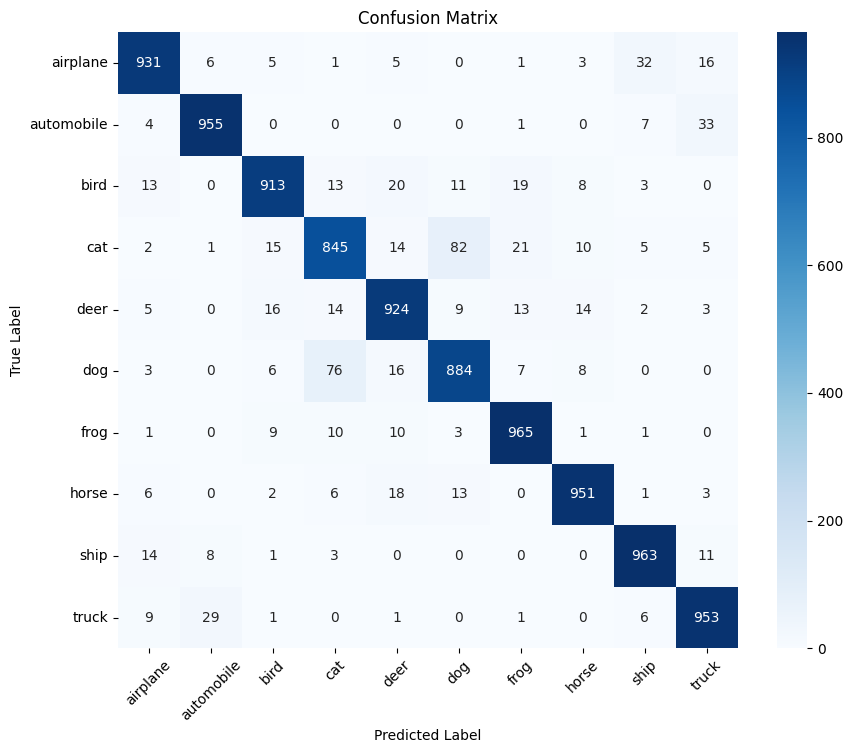

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
model_transfer.save('EfficientNetV2BOModel_unfreeze112_earlystopping.keras')
model_transfer.save('EfficientNetV2BOModel_unfreeze112_earlystopping.h5')

In [ ]:
# Log summary table to wandb
wandb.log({
    "summary_table": wandb.Table(
        columns=["Split", "Loss", "Accuracy"],
        data=[
            ["Train", round(train_loss, 4), round(train_acc, 4)],
            ["Test/Val", round(test_loss, 4), round(test_acc, 4)]
        ]
    )
})



## Store to wandb
artifact = wandb.Artifact(name=f"{name}", type="model")
artifact.add_file("EfficientNetV2BOModel_unfreeze112_earlystopping.keras")
artifact.add_file("EfficientNetV2BOModel_unfreeze112_earlystopping.h5")
wandb.log_artifact(artifact)


# Mark run as finished
wandb.finish()

epoch/accuracy,▁▂▃▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇████████
epoch/epoch,▁▁▁▁▂▂▂▂▂▂▂▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▆▆▇▇▇▇▇█
epoch/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/loss,█▇▆▅▅▄▄▄▄▄▃▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁
epoch/val_accuracy,▁▂▃▃▄▄▅▅▅▅▅▅▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇███████████
epoch/val_loss,█▆▆▅▅▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/accuracy,0.96256
epoch/epoch,81
epoch/learning_rate,1e-05
epoch/loss,0.10876
epoch/val_accuracy,0.9281
